In [44]:
import torch
import triton
import triton.language as tl

# forward pass

In [45]:
def layernorm_forward_torch(
    x: torch.Tensor,
    weight: torch.Tensor,
    bias: torch.Tensor,
    eps: float = 1e-5,
):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, unbiased=False, keepdim=True)

    rstd = 1.0 / torch.sqrt(var + eps)
    x_hat = (x - mean) * rstd

    return x_hat * weight + bias


@triton.autotune(
    configs=[
        triton.Config({}, num_warps=2),
        triton.Config({}, num_warps=4),
        triton.Config({}, num_warps=8),
    ],
    key=["N"],
)
@triton.jit
def layernorm_forward_kernel(
    x_ptr,
    weight_ptr,
    bias_ptr,
    output_ptr,
    mean_ptr,
    rstd_ptr,
    stride,
    N,
    eps,
    BLOCK_SIZE: tl.constexpr,
):
    pid = tl.program_id(0)

    row_start = pid * stride

    offsets = tl.arange(0, BLOCK_SIZE)
    mask = offsets < N

    x = tl.load(
        x_ptr + row_start + offsets,
        mask=mask,
        other=0.0,
    )

    mean = tl.sum(x, axis=0) / N

    x_centered = x - mean
    var = tl.sum(x_centered * x_centered, axis=0) / N

    rstd = 1.0 / tl.sqrt(var + eps)

    x_hat = x_centered * rstd

    weight = tl.load(weight_ptr + offsets, mask=mask)
    bias = tl.load(bias_ptr + offsets, mask=mask)

    output = x_hat * weight + bias

    tl.store(
        output_ptr + row_start + offsets,
        output,
        mask=mask,
    )

    tl.store(mean_ptr + pid, mean)
    tl.store(rstd_ptr + pid, rstd)


def layernorm_forward_triton(
    x: torch.Tensor,
    weight: torch.Tensor,
    bias: torch.Tensor,
    eps: float = 1e-5,
):
    M, N = x.shape

    output = torch.empty_like(x)

    mean = torch.empty(
        (M,),
        device=x.device,
        dtype=torch.float32,
    )

    rstd = torch.empty(
        (M,),
        device=x.device,
        dtype=torch.float32,
    )

    BLOCK_SIZE = triton.next_power_of_2(N)

    grid = (M,)

    layernorm_forward_kernel[grid](
        x,
        weight,
        bias,
        output,
        mean,
        rstd,
        x.stride(0),
        N,
        eps,
        BLOCK_SIZE=BLOCK_SIZE,
    )

    return output, mean, rstd

# backward pass

In [46]:
@triton.autotune(
    configs=[
        triton.Config({}, num_warps=2),
        triton.Config({}, num_warps=4),
        triton.Config({}, num_warps=8),
    ],
    key=["N"],
    reset_to_zero=["dweight_ptr", "dbias_ptr"],
)
@triton.jit
def layernorm_backward_kernel(
    x_ptr,
    dy_ptr,
    weight_ptr,
    mean_ptr,
    rstd_ptr,
    dx_ptr,
    dweight_ptr,
    dbias_ptr,
    stride,
    N,
    BLOCK_SIZE: tl.constexpr,
):
    pid = tl.program_id(0)

    row_start = pid * stride

    offsets = tl.arange(0, BLOCK_SIZE)
    mask = offsets < N

    x = tl.load(
        x_ptr + row_start + offsets,
        mask=mask,
        other=0.0,
    )

    dy = tl.load(
        dy_ptr + row_start + offsets,
        mask=mask,
        other=0.0,
    )

    weight = tl.load(
        weight_ptr + offsets,
        mask=mask,
    )

    mean = tl.load(mean_ptr + pid)
    rstd = tl.load(rstd_ptr + pid)

    x_hat = (x - mean) * rstd

    wdy = weight * dy

    c1 = tl.sum(x_hat * wdy, axis=0) / N
    c2 = tl.sum(wdy, axis=0) / N

    dx = (wdy - x_hat * c1 - c2) * rstd

    tl.store(
        dx_ptr + row_start + offsets,
        dx,
        mask=mask,
    )

    dweight = dy * x_hat
    dbias = dy

    tl.atomic_add(
        dweight_ptr + offsets,
        dweight,
        mask=mask,
    )

    tl.atomic_add(
        dbias_ptr + offsets,
        dbias,
        mask=mask,
    )


def layernorm_backward_triton(
    x,
    dy,
    weight,
    mean,
    rstd,
):
    M, N = x.shape

    dx = torch.empty_like(x)

    dweight = torch.zeros_like(weight)
    dbias = torch.zeros_like(weight)

    BLOCK_SIZE = triton.next_power_of_2(N)

    grid = (M,)

    layernorm_backward_kernel[grid](
        x,
        dy,
        weight,
        mean,
        rstd,
        dx,
        dweight,
        dbias,
        x.stride(0),
        N,
        BLOCK_SIZE=BLOCK_SIZE,
    )

    return dx, dweight, dbias

# tests

In [47]:
torch.manual_seed(0)

M = 4096
N = 512

x = torch.randn(
    M,
    N,
    device="cuda",
    requires_grad=True,
)

weight = torch.randn(
    N,
    device="cuda",
    requires_grad=True,
)

bias = torch.randn(
    N,
    device="cuda",
    requires_grad=True,
)

out_triton, mean, rstd = layernorm_forward_triton(
    x,
    weight,
    bias,
)

out_torch = layernorm_forward_torch(
    x,
    weight,
    bias,
)

torch.testing.assert_close(
    out_triton,
    out_torch,
    atol=1e-4,
    rtol=1e-4,
)

dy = torch.randn_like(x)

dx_triton, dw_triton, db_triton = layernorm_backward_triton(
    x,
    dy,
    weight,
    mean,
    rstd,
)

out_torch.backward(dy)

torch.testing.assert_close(
    dx_triton,
    x.grad,
    atol=1e-3,
    rtol=1e-3,
)

torch.testing.assert_close(
    dw_triton,
    weight.grad,
    atol=1e-3,
    rtol=1e-3,
)

torch.testing.assert_close(
    db_triton,
    bias.grad,
    atol=1e-3,
    rtol=1e-3,
)

print("all good, my man")

all good, my man


# benchmarks

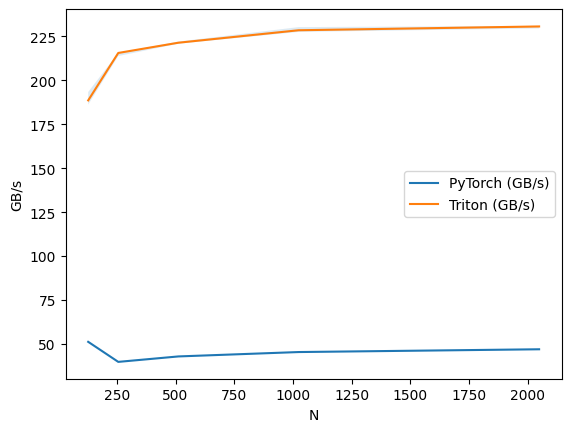

forward-pass-performance:
        N  PyTorch (GB/s)  Triton (GB/s)
0   128.0       51.200001     188.592807
1   256.0       39.791136     215.578957
2   512.0       42.890053     221.405396
3  1024.0       45.385040     228.497723
4  2048.0       46.963957     230.659033


In [48]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["N"],
        x_vals=[128, 256, 512, 1024, 2048],
        line_arg="provider",
        line_vals=["torch", "triton"],
        line_names=["PyTorch", "Triton"],
        ylabel="GB/s",
        plot_name="forward-pass-performance",
        args={},
    )
)
def benchmark_forward(N, provider):

    M = 4096

    x = torch.randn(M, N, device="cuda")

    weight = torch.randn(N, device="cuda")
    bias = torch.randn(N, device="cuda")

    quantiles = [0.5, 0.2, 0.8]

    if provider == "torch":

        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: layernorm_forward_torch(
                x,
                weight,
                bias,
            ),
            quantiles=quantiles,
        )

    else:

        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: layernorm_forward_triton(
                x,
                weight,
                bias,
            ),
            quantiles=quantiles,
        )

    gbps = lambda ms: (
        2 * x.numel() * x.element_size()
    ) / (ms * 1e-3) / 1e9

    return gbps(ms), gbps(max_ms), gbps(min_ms)


benchmark_forward.run(
    show_plots=True,
    print_data=True,
)

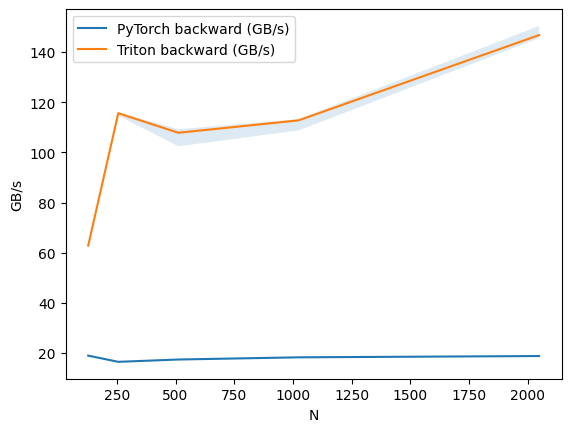

backward-pass-performance:
        N  PyTorch backward (GB/s)  Triton backward (GB/s)
0   128.0                18.992273               62.824092
1   256.0                16.516129              115.583772
2   512.0                17.441771              107.789472
3  1024.0                18.312966              112.733944
4  2048.0                18.827225              146.722393


In [49]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["N"],
        x_vals=[128, 256, 512, 1024, 2048],
        line_arg="provider",
        line_vals=["torch", "triton"],
        line_names=["PyTorch backward", "Triton backward"],
        ylabel="GB/s",
        plot_name="backward-pass-performance",
        args={},
    )
)
def benchmark_backward(N, provider):

    M = 4096

    x = torch.randn(
        M,
        N,
        device="cuda",
        requires_grad=True,
    )

    weight = torch.randn(
        N,
        device="cuda",
        requires_grad=True,
    )

    bias = torch.randn(
        N,
        device="cuda",
        requires_grad=True,
    )

    dy = torch.randn_like(x)

    quantiles = [0.5, 0.2, 0.8]

    if provider == "torch":

        def torch_backward():

            x.grad = None
            weight.grad = None
            bias.grad = None

            out = layernorm_forward_torch(
                x,
                weight,
                bias,
            )

            out.backward(dy)

        ms, min_ms, max_ms = triton.testing.do_bench(
            torch_backward,
            quantiles=quantiles,
        )

    else:

        out, mean, rstd = layernorm_forward_triton(
            x,
            weight,
            bias,
        )

        def triton_backward():

            layernorm_backward_triton(
                x,
                dy,
                weight,
                mean,
                rstd,
            )

        ms, min_ms, max_ms = triton.testing.do_bench(
            triton_backward,
            quantiles=quantiles,
        )

    gbps = lambda ms: (
        3 * x.numel() * x.element_size()
    ) / (ms * 1e-3) / 1e9

    return gbps(ms), gbps(max_ms), gbps(min_ms)


benchmark_backward.run(
    show_plots=True,
    print_data=True,
)